# LeWorldModel Hacking 9 — CEM Visualization (cleaned)

Two sections:
1. **Explore** which episode and goal offset to plan over (now supporting `goal_offset > 25`).
2. **Run** instrumented CEM on the chosen config, visualize as before, and **save everything to disk** for the manim animation.


## Setup (run once)

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import json
import time
from pathlib import Path
from copy import deepcopy
from collections import defaultdict
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Ellipse

import torch
import gymnasium as gym
from sklearn.preprocessing import StandardScaler
from torchvision.transforms import v2 as transforms

import stable_pretraining as spt
import stable_worldmodel as swm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
print("cache: ", swm.data.utils.get_cache_dir())


/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/le-wm/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu
cache:  /home/stephen/.stable_worldmodel


In [2]:
# --- env + dataset ----------------------------------------------------------
env = gym.make("swm/PushT-v1", render_mode="rgb_array")

ds = swm.data.HDF5Dataset(name="pusht_expert_train",
                          keys_to_cache=["action", "proprio", "state"])
ep_starts = np.concatenate([[0], np.cumsum(ds.lengths)]).astype(np.int64)

print(f"episodes:       {len(ds.lengths)}")
print(f"samples:        {len(ds)}")
print(f"ep length:      min={ds.lengths.min()}  median={int(np.median(ds.lengths))}  max={ds.lengths.max()}")


20:16:50.529 | INFO    (3366926, stable_pretraining) | Cached 'action' from '/home/stephen/.stable_worldmodel/pusht_expert_train.h5'
20:16:50.544 | INFO    (3366926, stable_pretraining) | Cached 'proprio' from '/home/stephen/.stable_worldmodel/pusht_expert_train.h5'
20:16:50.563 | INFO    (3366926, stable_pretraining) | Cached 'state' from '/home/stephen/.stable_worldmodel/pusht_expert_train.h5'
episodes:       18685
samples:        2336736
ep length:      min=49  median=123  max=246


In [3]:
# --- action scaler + empirical px/action calibration ------------------------
# action_scaler  : standardize/unstandardize action samples from CEM
# act_scale      : how many PushT-native pixels does one normalized action unit move
#                  the pusher (separate per x, y). Fit via 1D LS Δstate ≈ K · action.

all_actions = ds.get_col_data("action")
if all_actions.ndim == 3:
    all_actions = all_actions.reshape(-1, all_actions.shape[-1])
all_actions = all_actions[~np.isnan(all_actions).any(axis=1)]
action_scaler = StandardScaler().fit(all_actions)

EP_FOR_K = 0
row0_K = int(ep_starts[EP_FOR_K])
len_K  = int(ds.lengths[EP_FOR_K])

states_raw  = ds.get_col_data("state")
actions_raw = ds.get_col_data("action")
a_per_row   = actions_raw.sum(axis=1) if actions_raw.ndim == 3 else actions_raw

agent_xy_512 = states_raw[row0_K:row0_K + len_K, :2].astype(np.float64)
acts_ep      = a_per_row[row0_K:row0_K + len_K].astype(np.float64)
ok = ~(np.isnan(agent_xy_512).any(1) | np.isnan(acts_ep).any(1))
agent_xy_512, acts_ep = agent_xy_512[ok], acts_ep[ok]
deltas = np.diff(agent_xy_512, axis=0)
acts   = acts_ep[:-1]

K_x = (acts[:, 0] @ deltas[:, 0]) / (acts[:, 0] @ acts[:, 0])
K_y = (acts[:, 1] @ deltas[:, 1]) / (acts[:, 1] @ acts[:, 1])
act_scale = np.array([K_x, K_y])

pred   = acts * act_scale
ss_res = ((deltas - pred) ** 2).sum()
ss_tot = ((deltas - deltas.mean(0)) ** 2).sum()
print(f"act_scale (PushT px / norm. unit): x={K_x:.3f}  y={K_y:.3f}   R²={1 - ss_res/ss_tot:.4f}")

PUSHT_NATIVE = 512
IMG_SIZE     = 224
SCALE        = IMG_SIZE / PUSHT_NATIVE   # 0.4375


act_scale (PushT px / norm. unit): x=40.050  y=39.550   R²=0.9879


In [6]:
import sys
sys.path.append('/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/le-wm')

In [7]:
# --- image transform + cost model -------------------------------------------
img_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(**spt.data.dataset_stats.ImageNet),
    transforms.Resize(size=IMG_SIZE),
])

cost_model = swm.policy.AutoCostModel("pusht/lewm").to(DEVICE).eval()
cost_model.requires_grad_(False)
cost_model.interpolate_pos_encoding = True   # lets us use non-default horizons

# Callables to drive the env into a chosen dataset state at reset time.
CALLABLES = [
    {"method": "_set_state",      "args": {"state":      {"value": "state"}}},
    {"method": "_set_goal_state", "args": {"goal_state": {"value": "state"}}},
]


In [8]:
# --- episode helpers --------------------------------------------------------
def episode_info(episode_idx):
    return int(ep_starts[episode_idx]), int(ds.lengths[episode_idx])

def max_goal_offset(episode_idx, start_step=0):
    """Largest goal_offset that still fits inside the episode."""
    _, length = episode_info(episode_idx)
    return length - 1 - start_step

def render_frame(row):
    """Render frame at absolute dataset row -> (H, W, 3) uint8."""
    return ds[row]["pixels"].squeeze(0).permute(1, 2, 0).cpu().numpy()

def preview_episode(episode_idx, start_step=0, goal_offset=25, show_middle=True):
    row0, length = episode_info(episode_idx)
    if start_step + goal_offset >= length:
        raise ValueError(
            f"ep {episode_idx} length={length}, can't reach "
            f"start+offset={start_step + goal_offset}"
        )
    if show_middle:
        rows   = [row0 + start_step,
                  row0 + start_step + goal_offset // 2,
                  row0 + start_step + goal_offset]
        titles = [f"start t={start_step}",
                  f"mid   t={start_step + goal_offset // 2}",
                  f"goal  t={start_step + goal_offset}"]
    else:
        rows   = [row0 + start_step, row0 + start_step + goal_offset]
        titles = [f"start t={start_step}", f"goal  t={start_step + goal_offset}"]

    fig, axs = plt.subplots(1, len(rows), figsize=(3 * len(rows), 3))
    for ax, r, t in zip(axs, rows, titles):
        ax.imshow(render_frame(r)); ax.set_title(t); ax.axis("off")
    plt.suptitle(f"episode {episode_idx}   (length={length})")
    plt.tight_layout(); plt.show()

def preview_grid(specs):
    """specs is a list of (episode_idx, start_step, goal_offset)."""
    n = len(specs)
    fig, axs = plt.subplots(n, 2, figsize=(6, 3 * n))
    if n == 1: axs = axs[None, :]
    for i, (ep, st, off) in enumerate(specs):
        row0, length = episode_info(ep)
        if st + off >= length:
            axs[i, 0].text(0.5, 0.5, f"ep {ep} too short ({length})",
                           ha="center", va="center"); axs[i, 0].axis("off")
            axs[i, 1].axis("off"); continue
        axs[i, 0].imshow(render_frame(row0 + st))
        axs[i, 0].set_title(f"ep {ep}  start t={st}"); axs[i, 0].axis("off")
        axs[i, 1].imshow(render_frame(row0 + st + off))
        axs[i, 1].set_title(f"ep {ep}  goal t={st + off}  (Δ={off})"); axs[i, 1].axis("off")
    plt.tight_layout(); plt.show()


## Section 1 — Explore episode + goal offset

The original config plans `horizon × action_block = 5 × 5 = 25` micro-actions to match `goal_offset = 25`. Bumping `goal_offset` beyond 25 works as long as you bump `horizon` in step (keep `action_block = 5` so the model sees the chunking it was trained with). The cost model's positional encodings interpolate, so longer plans are fine.

A few episode/offset combinations to scan:


In [12]:
episode_idx=18002

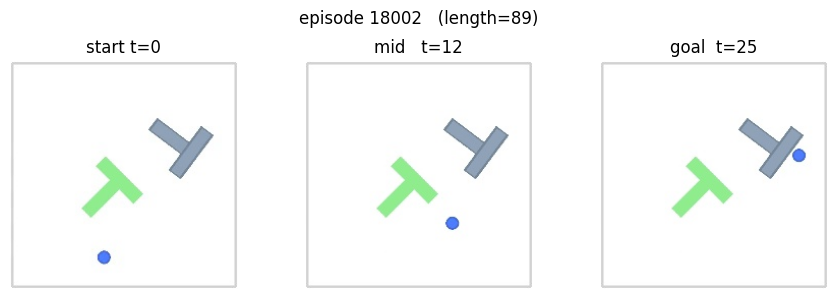

In [13]:
# Default config: episode 0, offset 25
preview_episode(episode_idx=episode_idx, start_step=0, goal_offset=25)


ep 0 max offset from t=0: 108


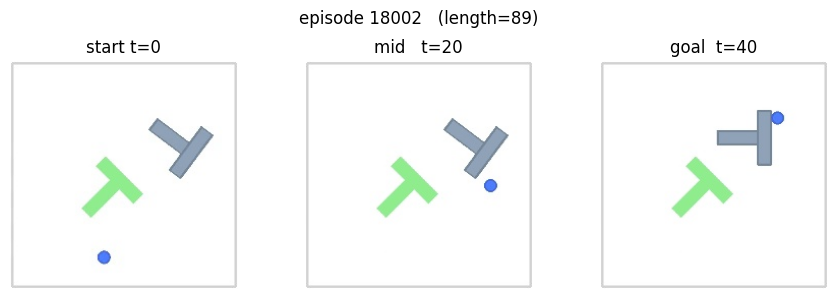

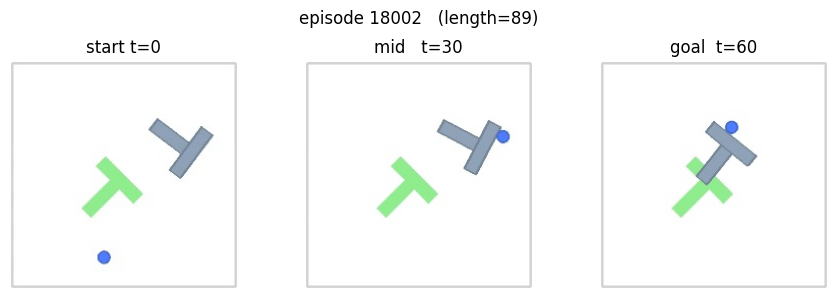

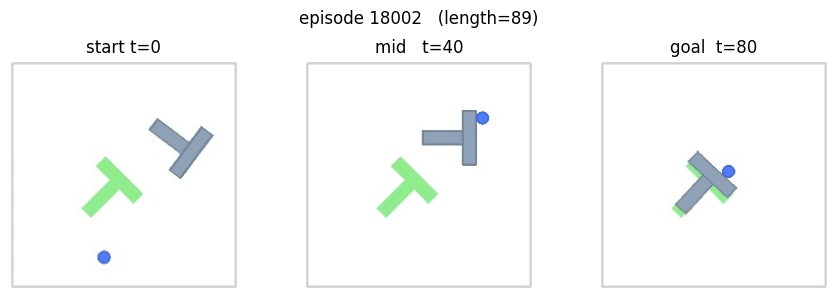

In [15]:
# Same episode, longer horizons
print(f"ep 0 max offset from t=0: {max_goal_offset(0, 0)}")
preview_episode(episode_idx=episode_idx, start_step=0, goal_offset=40)
preview_episode(episode_idx=episode_idx, start_step=0, goal_offset=60)
preview_episode(episode_idx=episode_idx, start_step=0, goal_offset=80)

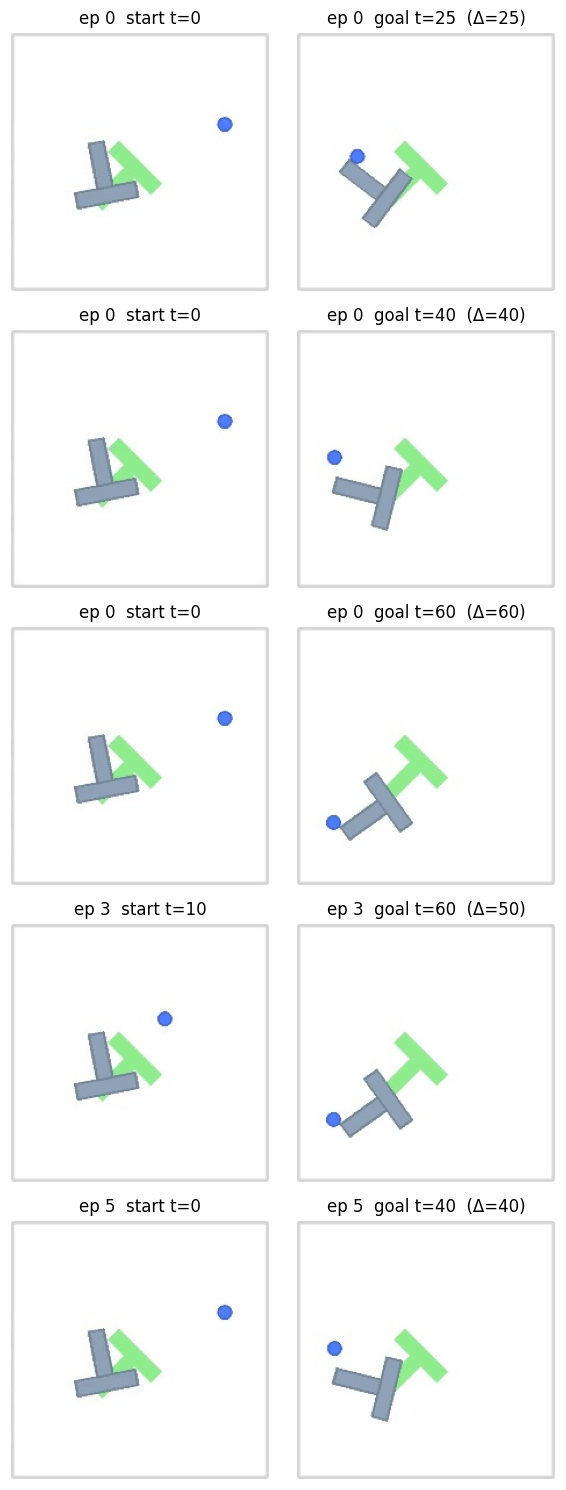

In [16]:
# Side-by-side comparison: easy starting point, harder one further into the episode.
preview_grid([
    (0,  0, 25),
    (0,  0, 40),
    (0,  0, 60),
    (3, 10, 50),
    (5,  0, 40),
])


## Section 2 — Run CEM and save data for manim

Lock the config, build the policy and world for it, run instrumented CEM, draw the iteration view, then dump everything needed for the manim animation.


In [36]:
# --- config -----------------------------------------------------------------
EPISODE_IDX  = 18002
START_STEP   = 0
GOAL_OFFSET  = 60           # bumped from the default 25

# CEM
HORIZON      = 12           # × ACTION_BLOCK = 40 micro-actions per plan
ACTION_BLOCK = 5
NUM_SAMPLES  = 300
N_STEPS      = 30
TOPK         = 30
VAR_SCALE    = 1.0
SEED         = 42

# Output
OUT_DIR = Path(f"/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/p75/ep{EPISODE_IDX}_off{GOAL_OFFSET}_h{HORIZON}")

if HORIZON * ACTION_BLOCK != GOAL_OFFSET:
    print(f"⚠  HORIZON*ACTION_BLOCK = {HORIZON*ACTION_BLOCK} ≠ GOAL_OFFSET = {GOAL_OFFSET}. "
          "Plan length and goal-frame distance no longer match — cost values will be "
          "comparing latents from different time horizons.")


In [37]:
# --- build policy / solver / world for this config --------------------------
plan_config = swm.PlanConfig(horizon=HORIZON,
                             receding_horizon=HORIZON,
                             action_block=ACTION_BLOCK)

solver = swm.solver.CEMSolver(
    model=cost_model,
    batch_size=1,
    num_samples=NUM_SAMPLES,
    var_scale=VAR_SCALE,
    n_steps=N_STEPS,
    topk=TOPK,
    device=DEVICE,
    seed=SEED,
)

policy = swm.policy.WorldModelPolicy(
    solver=solver,
    config=plan_config,
    process={"action": action_scaler},
    transform={"pixels": img_transform, "goal": img_transform},
)

world = swm.World(
    env_name="swm/PushT-v1",
    num_envs=1,
    max_episode_steps=2 * GOAL_OFFSET,
    history_size=1,
    frame_skip=1,
    image_shape=(IMG_SIZE, IMG_SIZE),
)
world.set_policy(policy)


20:28:11.086 | INFO    (3366926, stable_worldmodel.world) | 🌍🌍🌍 World swm/PushT-v1 initialized 🌍🌍🌍
20:28:11.087 | INFO    (3366926, stable_worldmodel.world) | 🕹️ 🕹️ 🕹️ Action space 🕹️ 🕹️ 🕹️
20:28:11.087 | INFO    (3366926, stable_worldmodel.world) | Box(-1.0, 1.0, (1, 2), float32)
20:28:11.087 | INFO    (3366926, stable_worldmodel.world) | 👁️ 👁️ 👁️ Observation space 👁️ 👁️ 👁️
20:28:11.088 | INFO    (3366926, stable_worldmodel.world) | Dict('proprio': Box(0.0, 512.0, (1, 4), float64), 'state': Box(0.0, [[512.         512.         512.         512.           6.28318531
  512.         512.        ]], (1, 7), float64))
20:28:11.088 | INFO    (3366926, stable_worldmodel.world) | ⚗️ ⚗️ ⚗️ Variation space ⚗️ ⚗️ ⚗️


agent:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(8)
    start_position: Box(50.0, 450.0, (2,), float64)
    velocity: Box(0.0, 512.0, (2,), float64)
background:
    color: Box(0, 255, (3,), uint8)
block:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(7, start=1)
    start_position: Box(100.0, 400.0, (2,), float64)
goal:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    position: Box(50.0, 450.0, (2,), float64)
    scale: Box(20.0, 60.0, (), float32)
rendering:
    render_goal: Discrete(2)

agent (image px): [ 92.3125 192.9375]


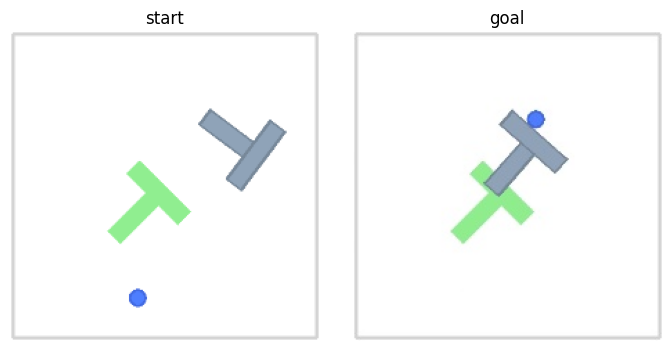

In [38]:
# --- reset world to the chosen dataset episode + set goal -------------------
def setup_world_for_episode(world, dataset, episode_idx, start_step, goal_offset, callables):
    """
    Replicates the relevant chunk of world.evaluate_from_dataset() for a single env.
    Returns the loaded chunk plus the (pre-broadcast) init_step / goal_step dicts.
    """
    ep_idx_arr      = np.array([episode_idx])
    start_steps_arr = np.array([start_step])
    end_steps       = start_steps_arr + goal_offset

    data    = dataset.load_chunk(ep_idx_arr, start_steps_arr, end_steps)
    columns = dataset.column_names

    init_per: dict[str, list[Any]] = defaultdict(list)
    goal_per: dict[str, list[Any]] = defaultdict(list)
    for ep in data:
        for col in columns:
            if col.startswith("goal"):
                continue
            if col.startswith("pixels"):
                ep[col] = ep[col].permute(0, 2, 3, 1)
            if not isinstance(ep[col], (torch.Tensor, np.ndarray)):
                continue
            init_d, goal_d = ep[col][0], ep[col][-1]
            if isinstance(init_d, torch.Tensor):
                init_d, goal_d = init_d.numpy(), goal_d.numpy()
            init_per[col].append(init_d)
            goal_per[col].append(goal_d)

    init_step = {k: np.stack(v) for k, v in deepcopy(init_per).items()}
    goal_step = {("goal" if k == "pixels" else f"goal_{k}"): np.stack(v)
                 for k, v in goal_per.items()}

    seeds = init_step.get("seed")
    variations = {k.removeprefix("variation."): v
                  for k, v in init_step.items() if k.startswith("variation.")}

    options = [{} for _ in range(world.num_envs)]
    if variations:
        for i in range(world.num_envs):
            options[i]["variation"] = list(variations.keys())
            options[i]["variation_values"] = {k: v[i] for k, v in variations.items()}

    init_step_for_reset = deepcopy(init_step)
    init_step_for_reset.update(deepcopy(goal_step))
    world.reset(seed=seeds, options=options)

    # Apply callables (sets pusher + T pose, sets goal pose)
    for i, env in enumerate(world.envs.unwrapped.envs):
        env_unwrapped = env.unwrapped
        for spec in callables:
            method = getattr(env_unwrapped, spec["method"], None)
            if method is None:
                continue
            prepared = {}
            for name, ad in spec.get("args", {}).items():
                val = ad.get("value", None)
                if ad.get("in_dataset", True):
                    if val not in init_step_for_reset:
                        continue
                    prepared[name] = deepcopy(init_step_for_reset[val][i])
                else:
                    prepared[name] = val
            method(**prepared)

    # Broadcast init/goal to (n_envs, history, ...) and write into world.infos
    shape_prefix = world.infos["pixels"].shape[:2]
    init_b = {k: np.broadcast_to(v[:, None], shape_prefix + v.shape[1:])
              for k, v in init_step.items()}
    goal_b = {k: np.broadcast_to(v[:, None], shape_prefix + v.shape[1:])
              for k, v in goal_step.items()}
    world.infos.update(deepcopy(init_b))
    world.infos.update(deepcopy(goal_b))

    return data, init_step, goal_step

data, init_step, goal_step = setup_world_for_episode(
    world, ds, EPISODE_IDX, START_STEP, GOAL_OFFSET, CALLABLES,
)

# canvas we'll overlay onto, goal frame we want to reach
canvas   = world.envs.render()[0]            # (224, 224, 3) uint8
goal_img = goal_step["goal"][0]               # (224, 224, 3) uint8

# pusher start in image coords (taken from dataset state, not re-rendered)
row0 = ep_starts[EPISODE_IDX]
start_state  = ds[row0 + START_STEP]["state"].squeeze(0).cpu().numpy()
goal_state   = ds[row0 + START_STEP + GOAL_OFFSET]["state"].squeeze(0).cpu().numpy()
agent_xy_img = start_state[:2] * SCALE
print("agent (image px):", agent_xy_img)

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))
axs[0].imshow(canvas);   axs[0].set_title("start"); axs[0].axis("off")
axs[1].imshow(goal_img); axs[1].set_title("goal");  axs[1].axis("off")
plt.tight_layout(); plt.show()


In [39]:
# --- run instrumented CEM (records per-iter internals) ----------------------
def run_instrumented_cem(world, init_action=None):
    info_dict = world.policy._prepare_info(world.infos)

    s = world.policy.solver
    mean, var = s.init_action_distrib(init_action)
    mean, var = mean.to(s.device), var.to(s.device)

    history = {k: [] for k in ["candidates", "costs", "topk_inds",
                               "topk_candidates", "means", "vars"]}

    # We only use total_envs=1 here.
    bs = s.n_envs
    batch_mean, batch_var = mean[:bs], var[:bs]

    expanded = {}
    for k, v in info_dict.items():
        vb = v[:bs]
        if torch.is_tensor(v):
            vb = vb.unsqueeze(1).expand(bs, s.num_samples, *vb.shape[1:])
        elif isinstance(v, np.ndarray):
            vb = np.repeat(vb[:, None, ...], s.num_samples, axis=1)
        expanded[k] = vb

    t0 = time.time()
    for step in range(s.n_steps):
        cands = torch.randn(bs, s.num_samples, s.horizon, s.action_dim,
                            generator=s.torch_gen, device=s.device)
        cands = cands * batch_var.unsqueeze(1) + batch_mean.unsqueeze(1)
        cands[:, 0] = batch_mean   # keep current mean as one of the samples

        costs = s.model.get_cost(expanded.copy(), cands)
        topk_vals, topk_inds = torch.topk(costs, k=s.topk, dim=1, largest=False)
        b_idx      = torch.arange(bs, device=s.device).unsqueeze(1).expand(-1, s.topk)
        topk_cands = cands[b_idx, topk_inds]

        batch_mean = topk_cands.mean(dim=1)
        batch_var  = topk_cands.std(dim=1)   # std despite the name — keeping consistent w/ original

        history["candidates"     ].append(cands.detach().cpu())
        history["costs"          ].append(costs.detach().cpu())
        history["topk_inds"      ].append(topk_inds.detach().cpu())
        history["topk_candidates"].append(topk_cands.detach().cpu())
        history["means"          ].append(batch_mean.detach().cpu())
        history["vars"           ].append(batch_var.detach().cpu())

    elite_cost = topk_vals.mean().item()
    print(f"CEM solve: {time.time() - t0:.2f}s   final elite cost = {elite_cost:.4f}")
    return history

history = run_instrumented_cem(world)


CEM solve: 11.49s   final elite cost = 151.0791


In [40]:
# --- project candidates from action-space to image-space (pixels) -----------
H, N, K        = HORIZON, NUM_SAMPLES, TOPK
A_BLOCK, A_DIM = ACTION_BLOCK, 2
N_ACTS         = H * A_BLOCK

def candidates_to_image_xy(cands, start_xy_img):
    """(batch, H, A_BLOCK*A_DIM) standardized  ->  (batch, N_ACTS, 2) image px."""
    a = cands.detach().cpu().numpy()
    a = a.reshape(a.shape[0], N_ACTS, A_DIM)
    a = action_scaler.inverse_transform(a.reshape(-1, A_DIM))
    a = a.reshape(-1, N_ACTS, A_DIM)
    deltas_img = a * act_scale * SCALE
    return np.cumsum(deltas_img, axis=1) + start_xy_img[None, None, :]

# Build per-iteration arrays in image coords — what we plot and what manim consumes.
paths_all_per, paths_elite_per, paths_mean_per = [], [], []
costs_per, topk_inds_per, cum_sigma_per        = [], [], []

for it in range(N_STEPS):
    cands   = history["candidates"     ][it][0]
    costs   = history["costs"          ][it][0].numpy()
    elites  = history["topk_candidates"][it][0]
    mean_b  = history["means"          ][it][0:1]   # keep batch dim
    var_b   = history["vars"           ][it][0]

    paths_all_per.append(  candidates_to_image_xy(cands,  agent_xy_img))
    paths_elite_per.append(candidates_to_image_xy(elites, agent_xy_img))
    paths_mean_per.append( candidates_to_image_xy(mean_b, agent_xy_img)[0])
    costs_per.append(costs)
    topk_inds_per.append(history["topk_inds"][it][0].numpy())

    sigma_norm    = var_b.numpy().reshape(N_ACTS, A_DIM)
    sigma_img     = sigma_norm * action_scaler.scale_ * act_scale * SCALE
    cum_sigma_per.append(np.sqrt(np.cumsum(sigma_img ** 2, axis=0)))

paths_all_per   = np.stack(paths_all_per)     # (n_steps, N, N_ACTS, 2)
paths_elite_per = np.stack(paths_elite_per)   # (n_steps, K, N_ACTS, 2)
paths_mean_per  = np.stack(paths_mean_per)    # (n_steps, N_ACTS, 2)
costs_per       = np.stack(costs_per)         # (n_steps, N)
topk_inds_per   = np.stack(topk_inds_per)     # (n_steps, K)
cum_sigma_per   = np.stack(cum_sigma_per)     # (n_steps, N_ACTS, 2)

print("paths_all   :", paths_all_per.shape)
print("paths_elite :", paths_elite_per.shape)
print("paths_mean  :", paths_mean_per.shape)
print("costs       :", costs_per.shape)


paths_all   : (30, 300, 60, 2)
paths_elite : (30, 30, 60, 2)
paths_mean  : (30, 60, 2)
costs       : (30, 300)


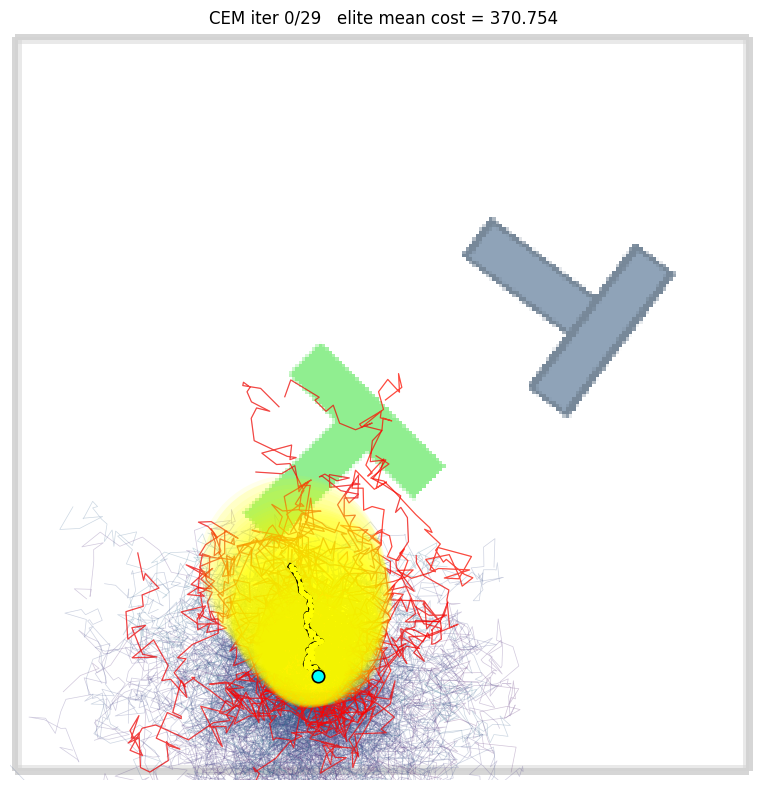

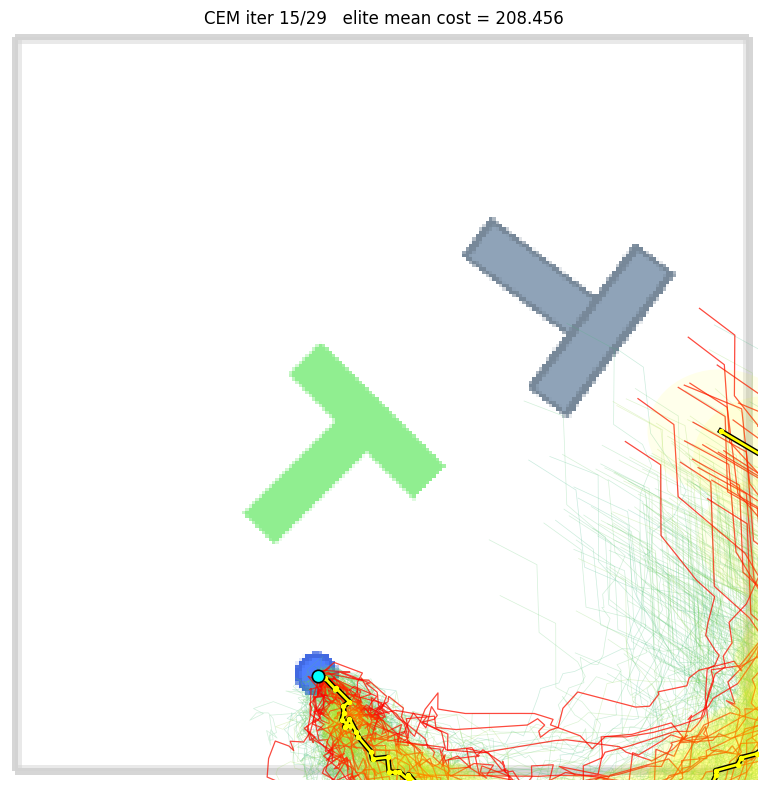

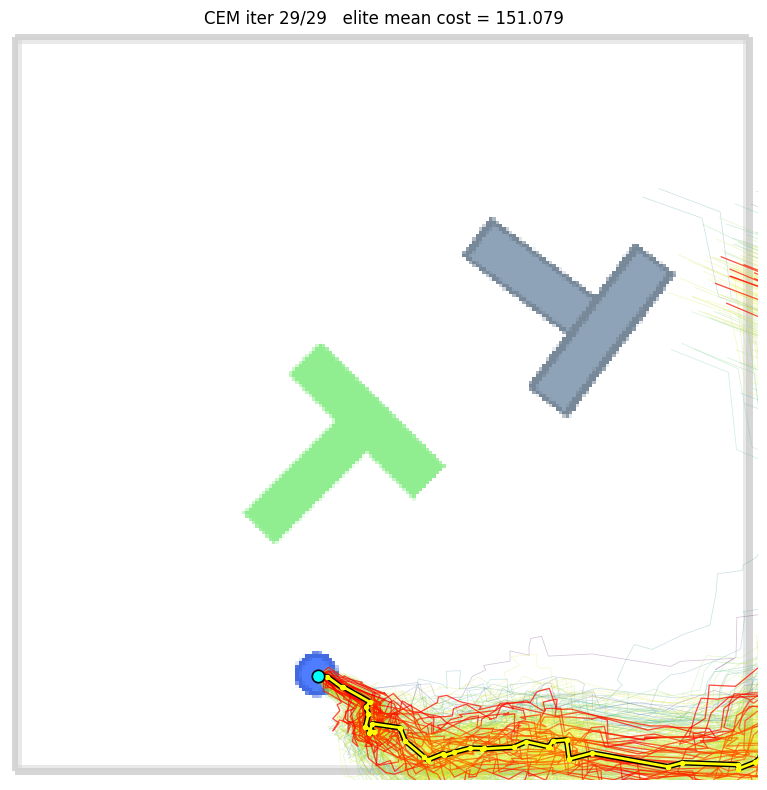

In [41]:
# --- plot a single CEM iteration (same look as the original notebook) -------
def plot_cem_iteration(iter_idx, ax=None, show=True):
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(canvas)

    paths_all   = paths_all_per  [iter_idx]
    paths_elite = paths_elite_per[iter_idx]
    path_mean   = paths_mean_per [iter_idx]
    costs       = costs_per      [iter_idx]
    cum_sigma   = cum_sigma_per  [iter_idx]

    start_pt = np.broadcast_to(agent_xy_img[None, None, :], (N, 1, 2))
    segs_all = np.concatenate([start_pt, paths_all], axis=1)
    segs_el  = np.concatenate([start_pt[:K], paths_elite], axis=1)
    segs_m   = np.concatenate([agent_xy_img[None, :], path_mean])

    order = np.argsort(-costs)
    cmap  = plt.get_cmap("viridis_r")
    norm  = plt.Normalize(vmin=costs.min(), vmax=costs.max())
    ax.add_collection(LineCollection(segs_all[order], colors=cmap(norm(costs))[order],
                                     linewidths=0.5, alpha=0.25))
    ax.add_collection(LineCollection(segs_el, colors="red", linewidths=0.9, alpha=0.7))
    ax.plot(segs_m[:, 0], segs_m[:, 1], "-",  color="black",  linewidth=4, zorder=4)
    ax.plot(segs_m[:, 0], segs_m[:, 1], "-o", color="yellow", linewidth=2,
            markersize=3, zorder=5)
    for i in range(N_ACTS):
        ax.add_patch(Ellipse(xy=path_mean[i],
                             width =2 * cum_sigma[i, 0],
                             height=2 * cum_sigma[i, 1],
                             facecolor="yellow", edgecolor="none",
                             alpha=0.08, zorder=3))
    ax.scatter([agent_xy_img[0]], [agent_xy_img[1]],
               s=80, c="cyan", edgecolors="black", linewidths=1.2, zorder=6)
    ax.set_xlim(0, IMG_SIZE); ax.set_ylim(IMG_SIZE, 0); ax.axis("off")
    elite_mean = costs[topk_inds_per[iter_idx]].mean()
    ax.set_title(f"CEM iter {iter_idx}/{N_STEPS - 1}   elite mean cost = {elite_mean:.3f}")
    if created and show:
        plt.tight_layout(); plt.show()

# Three snapshots: cloud → narrowing → converged
plot_cem_iteration(0)
plot_cem_iteration(N_STEPS // 2)
plot_cem_iteration(N_STEPS - 1)


In [42]:
# --- save everything for manim ---------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)
frames_dir = OUT_DIR / "frames"
frames_dir.mkdir(exist_ok=True)

# 1. start canvas + goal frame
plt.imsave(OUT_DIR / "canvas.png", canvas)
plt.imsave(OUT_DIR / "goal.png",   goal_img)

# 2. per-iteration arrays (image-space paths + raw distributions)
np.savez_compressed(
    OUT_DIR / "iterations.npz",
    paths_all   = paths_all_per  .astype(np.float32),
    paths_elite = paths_elite_per.astype(np.float32),
    paths_mean  = paths_mean_per .astype(np.float32),
    costs       = costs_per      .astype(np.float32),
    topk_inds   = topk_inds_per  .astype(np.int32),
    cum_sigma   = cum_sigma_per  .astype(np.float32),
    # raw action-space stats (in case manim wants to re-derive things)
    raw_means   = torch.stack(history["means"]).cpu().numpy().astype(np.float32),
    raw_vars    = torch.stack(history["vars" ]).cpu().numpy().astype(np.float32),
)

# 3. config / metadata
config_out = {
    "episode_idx":         EPISODE_IDX,
    "start_step":          START_STEP,
    "goal_offset":         GOAL_OFFSET,
    "horizon":             HORIZON,
    "action_block":        ACTION_BLOCK,
    "n_acts_per_plan":     N_ACTS,
    "num_samples":         NUM_SAMPLES,
    "n_steps":             N_STEPS,
    "topk":                TOPK,
    "var_scale":           VAR_SCALE,
    "seed":                SEED,
    "img_size":            IMG_SIZE,
    "pusht_native":        PUSHT_NATIVE,
    "scale":               float(SCALE),
    "agent_xy_img":        agent_xy_img.tolist(),
    "start_state":         start_state.tolist(),
    "goal_state":          goal_state .tolist(),
    "act_scale":           act_scale.tolist(),
    "action_scaler_mean":  action_scaler.mean_ .tolist(),
    "action_scaler_scale": action_scaler.scale_.tolist(),
}
with open(OUT_DIR / "config.json", "w") as f:
    json.dump(config_out, f, indent=2)

# 4. per-iteration PNGs (handy for scrubbing / sanity-check)
for it in range(N_STEPS):
    fig, ax = plt.subplots(figsize=(8, 8))
    plot_cem_iteration(it, ax=ax, show=False)
    fig.savefig(frames_dir / f"{it:03d}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

print(f"\nsaved to {OUT_DIR.resolve()}")
print("  canvas.png, goal.png")
print("  iterations.npz")
print("  config.json")
print(f"  frames/000.png … {N_STEPS - 1:03d}.png")



saved to /home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/p75/ep18002_off60_h12
  canvas.png, goal.png
  iterations.npz
  config.json
  frames/000.png … 029.png


## What got saved + how manim consumes it

```
cem_run_data/ep0_off40_h8/
├── canvas.png            # start frame (IMG_SIZE × IMG_SIZE × 3, uint8)
├── goal.png              # goal frame
├── iterations.npz        # per-iteration arrays for the animation
│     paths_all     (n_steps, N, N_ACTS, 2)    all candidate paths in image px
│     paths_elite   (n_steps, K, N_ACTS, 2)    top-K paths
│     paths_mean    (n_steps,    N_ACTS, 2)    mean path
│     costs         (n_steps, N)               cost of every candidate
│     topk_inds     (n_steps, K)               which candidates became elites
│     cum_sigma     (n_steps, N_ACTS, 2)       per-step std along the mean path
│     raw_means     (n_steps, 1, H, A_BLOCK*A_DIM)  raw action-space dist mean
│     raw_vars      (n_steps, 1, H, A_BLOCK*A_DIM)  raw action-space dist std
├── config.json           # episode/CEM config + calibration constants
└── frames/000.png … NNN.png    PNG per iteration (matches the matplotlib view)
```

For the manim scene, load `iterations.npz` and `config.json`, drop `canvas.png` as the background `ImageMobject`, and animate per iteration:

- fade the previous frame's candidate `VGroup` out → fade the new candidates in (colored by `costs[i]`)
- highlight `paths_elite[i]` in red
- transform the previous mean path to `paths_mean[i]`
- shrink the variance ellipses using `cum_sigma[i]`

`agent_xy_img` from `config.json` gives the cyan start dot. Image coordinates are pixel-space with origin top-left, matching `imshow` — invert y if manim's convention differs.
